In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [14]:
csv_path = r"D:\LTNcoder\data\eventlogs\method_heuristic_plateu.csv"

In [15]:
data = pd.read_csv(csv_path)
print(data)

       𝜏      r
0   0.00  1.000
1   0.15  0.140
2   0.20  0.100
3   0.40  0.090
4   0.60  0.085
5   0.70  0.080
6   0.72  0.078
7   0.74  0.075
8   0.80  0.070
9   0.86  0.068
10  0.90  0.066
11  0.95  0.060
12  1.00  0.000


C:\Users\devas\AppData\Local\Temp\ipykernel_57264\3043728871.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Method")


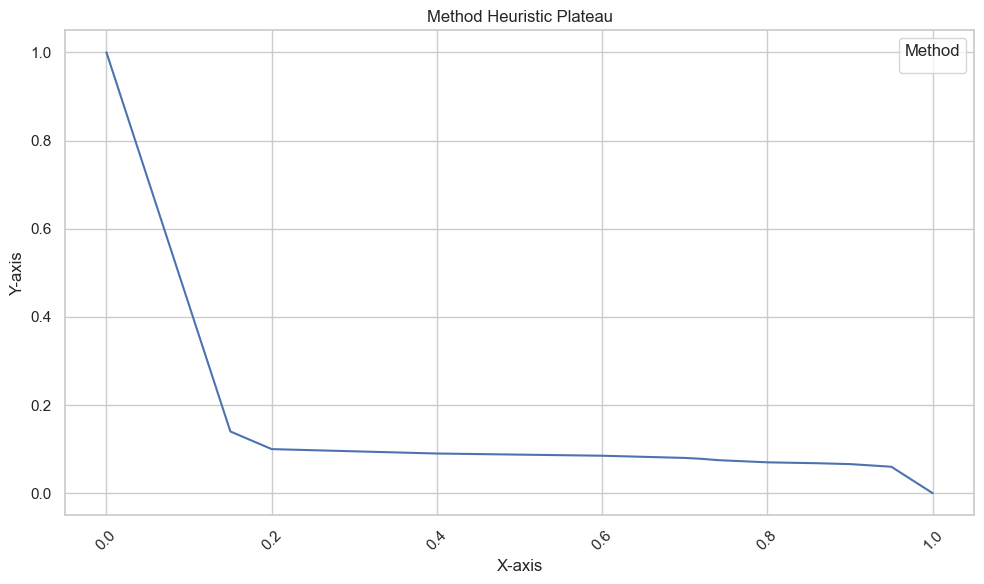

In [16]:
# plot the plot in seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
#smooth line plot
sns
sns.lineplot(data=data, x="𝜏", y="r")

plt.title("Method Heuristic Plateau")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend(title="Method")
plt.xticks(rotation=45)
plt.tight_layout()  
# plt.savefig(r"D:\LTNcoder\data\eventlogs\method_heuristic_plateu.png")
plt.show()

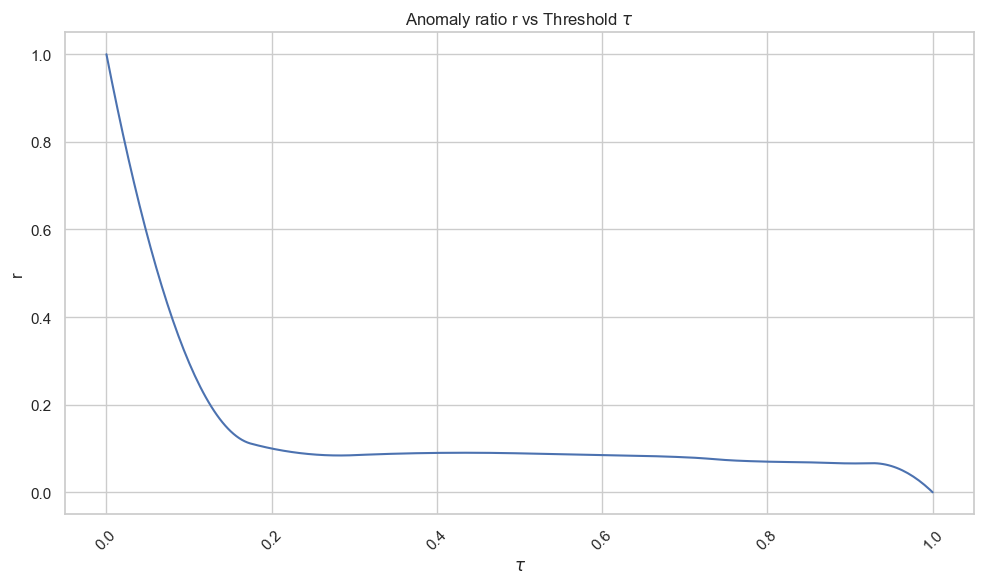

In [30]:
from scipy.interpolate import make_interp_spline
x = data["𝜏"]
y = data["r"]

# Interpolation
x_new = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=2
                         )  # k=3 means cubic spline
y_smooth = spl(x_new)

# Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.plot(x_new, y_smooth)

plt.title("Anomaly ratio r vs Threshold" + r" $\tau$")
# plt.xlabel(u"𝜏")
plt.xlabel(r"$\tau$")
plt.ylabel("r")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

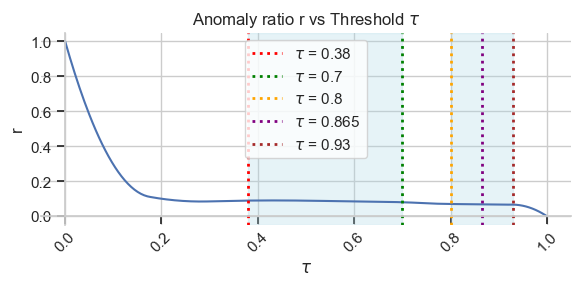

In [38]:
# Create the plot and get the axes object
fig, ax = plt.subplots(figsize=(6, 3))
sns.set_theme(style="whitegrid")

# Plot the smooth curve
ax.plot(x_new, y_smooth)

# Add shaded regions
ax.axvspan(0.38, 0.7, color="lightblue", alpha=0.3)
ax.axvspan(0.8, 0.93, color="lightblue", alpha=0.3)

# Vertical lines
thresholds = [0.38, 0.7, 0.8, 0.865, 0.93]
colors = ["red", "green", "orange", "purple", "brown"]
for t, c in zip(thresholds, colors):
    ax.axvline(x=t, color=c, linestyle="dotted", linewidth=2, label=f"$\\tau$ = {t}")

# === Make axes cross at (0, 0) ===
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Optional: move ticks outside
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Labels, legend, etc.
ax.set_title("Anomaly ratio r vs Threshold " + r"$\tau$")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("r")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


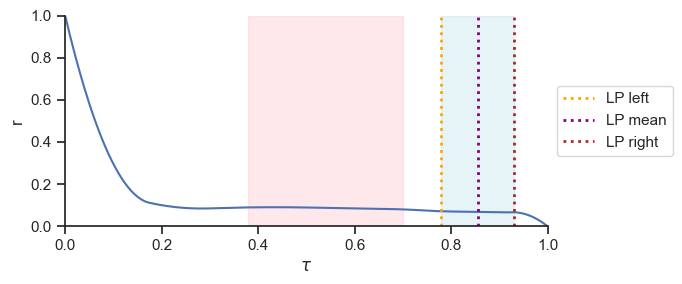

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot and get the axes object
fig, ax = plt.subplots(figsize=(7, 3))
sns.set_theme(style="white")

# Plot the smooth curve
ax.plot(x_new, y_smooth)

# Add shaded regions
ax.axvspan(0.38, 0.7, color="lightpink", alpha=0.3)
ax.axvspan(0.78, 0.93, color="lightblue", alpha=0.3)

# Vertical lines with dummy labels
# thresholds = [0.38, 0.7, 0.8, 0.865, 0.93]
# colors = ["red", "green", "orange", "purple", "brown"]
# labels = ["Phase A", "Phase B", "LP left", "LP mean", "LP right"]


thresholds = [ 0.78, 0.855, 0.93]
colors = [ "orange", "purple", "brown"]
labels = [ "LP left", "LP mean", "LP right"]

for t, c, label in zip(thresholds, colors, labels):
    ax.axvline(x=t, color=c, linestyle="dotted", linewidth=2, label=label)

# === Make axes cross at (0, 0) ===
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
# Optional: move ticks outside
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Remove background grid
ax.grid(False)

# Set labels and ticks
# ax.set_title("Anomaly ratio r vs Threshold " + r"$\tau$")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("r")
# plt.xticks(rotation=45)

# Legend outside the right side
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

# Layout adjustment
plt.tight_layout()
plt.savefig("D:\\masterarbeit\\figures\\method_anomaly_ratio_plot.png", format="png", dpi=400, bbox_inches='tight')
plt.show()
